# Przygotowanie

Przygotowanie Przed rozpoczęciem pracy z notatnikiem proszę zmienić jego nazwę dodając na początku numer albumu, imię i nazwisko. {nr_albumu}_{imię}_{nazwisko}_{nazwa}

Po wykonaniu wszystkich zadań proszę przesłać wypełniony notatnik przez platformę ELF za pomocą formularza "Prześlij projekt" w odpowiedniej sekcji.

# Drzewa decyzyjne

Podobnie jak w przypadku maszyny wektorów nosnych (SVC), drzewa decyzyjne sa wszechstronnym algorytmem uczenia maszynowego. Mogą słuzyc do rozwiazywania problemów zarówno klasyfikacji, jak i regresji. W przeciwieństwie do modelu SVC drzewa decyzyjne nie wymagają restrykcyjnego przygotowania danych (np. skalowania cech). Drzewa decyzyjne składaja sie z korzenia oraz gałezi prowadzacych do kolejnych wierzchołków. W wezłach - wierzchołkach z których wychodzi co najmniej jedna krawedź, sprawdzany jest pewien warunek. Na jego podstawie, wybierana jest gałaz prowadząca do kolejnego wierzchołka. Dana obserwacja zostaje zaklasyfikowana do konkretnej klasy po przejściu od korzenia do liscia i przypisaniu do tej obserwacji klasy, z danego liscia (nie wychodza z niego wezły potomne).

Za pomocą drzew decyzyjnych otrzymać możemy potężne modele zdolne do nauki złożonych zbiorów danych.

###  Las losowy

Klasyfikator lasu losowego jest klasyfikatorem zespołowym złozonym z drzew decyzyjnych. Klasyfikator ten wprowadza dodatkową losowość do wzrostu drzew. Nie wyszukuje on najlepszej cechy podczas podziału na wezły, ale szuka najlepszej cechy wsród losowego podziału cech. Powoduje to wieksze zróznicowanie powstałych w klasyfikatorze drzew. Losowe lasy są bardziej odporne na nadmierne dopasowanie się do zbioru treningowego, jakie spotykane jest podczas użycia drzew decyzyjnych.

In [2]:
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

print('Class labels:', np.unique(y))

Class labels: [0 1 2]


In [3]:
unique, counts = np.unique(y, return_counts=True)
dict(zip(unique, counts))

{np.int64(0): np.int64(50),
 np.int64(1): np.int64(50),
 np.int64(2): np.int64(50)}

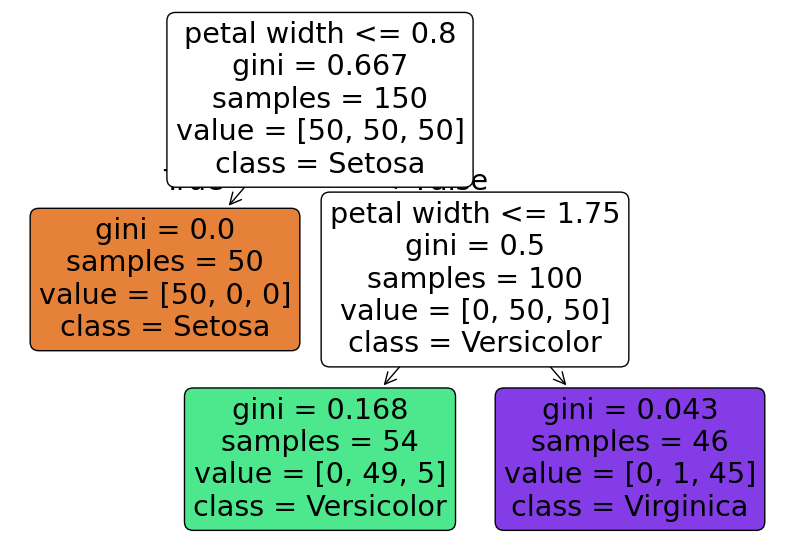

In [4]:
import matplotlib.pyplot as plt
from pydotplus import graph_from_dot_data
from sklearn.tree import DecisionTreeClassifier, export_graphviz

from sklearn.tree import plot_tree

tree = DecisionTreeClassifier(criterion='gini', max_depth=2, random_state=1)
tree.fit(X, y)

plt.figure(figsize=(10, 7))

plot_tree(tree, 
          filled=True, 
          rounded=True,
          class_names=['Setosa', 
                       'Versicolor',
                       'Virginica'],
          feature_names=['petal length', 
                         'petal width']) 

plt.show()

### Jak podejmowane są decyzje w drzewie?

Klasyfikacja próbki zaczyna się zawsze od korzenia (węzeł na samej górze grafu). W węźle zadawane jest pytanie (w przykładnie powyżej czy długość płatka jest mniejsza od 0.8). Jeśli prawda przechodzimy do węzła potomnego lewego, w przeciwnym razie do prawego. Przechodząc do węzła lewego dochodzimy do **liścia** (leaf node, nie posiada węzłów potomnych) - w taki wypadku żadne pytanie nie jest zadawane, przydzielana jest już tylko klasa do danej obserwacji. 

W przypadku, gdy skierujemy się ku węzłowi prawemu (nie jest już liściem) zadajemy kolejne pytanie, aż dojdziemy do liścia.

Znaczenie atrybutów:

- *samples* - oznacza ilość wyznaczonych próbek dla danego węzła (zgadza się to w przedstawionym przypadku z ilością próbek dla danych klas)
- *value* - określa ilość przykładów uczących z każdej klasy jakie przynależą do danego węzła.
- *gini* - miara zanieczyszczenia węzła (0 oznacza, że wszystkie próbki w węźle należą do jednej klasy - idealna klasyfikacja)

Wskaźnik Gingiego:
    \begin{equation*}
 G_{i} = 1 - \sum_{k=1}^{n} p_{i, k}^{2}
\end{equation*}
gdzie $p_{i,k}$ oznacza współczynie występowania klas k, wśród próbek uczących w węźle i.

Jako wskaźnik zanieczyszczenia (parametr *entropy*), użyta może zostać również miara entropii. Wynosi ona 0, w przypadku, gdy wszystkie informacje są takie same - wszystkie próbiki w węźle należą do jednej klasy.

Entropia:
    
\begin{equation*}
    H_{i} = - \sum_{k=1\\ p_{i,k} \neq 0}^{n} p_{i, k} log(p_{i,k})
\end{equation*}


Różnice pomędzy tymi dwoma miarami są zazwyczaj bardzo znikome i nie wypływają znacząco na skuteczność działania klasyfikatora. Dla zainteresowanych szczegółami zapraszam do lektury: https://sebastianraschka.com/faq/docs/decision-tree-binary.html, https://towardsdatascience.com/the-simple-math-behind-3-decision-tree-splitting-criterions-85d4de2a75fe

W jakim momencie przestać budować drzewo decyzyje?

Problemy rozważane w uczeniu maszynowym mają zazwyczaj sporą liczbę cech, która może powodować wysoko rosnące skomplikowanie drzewa (jego wielkość, sporą ilość węzłów oraz podziałów w węzłach). Tak utworzone drzewa mogą powodować nadmierne dopasowanie do danych treningowych.

Algorytm drzewa decyzyjnego posiada parametry, które ustalane są podczas uczenia. Jak wspomniano, może powodować to przetrenowanie klasyfikatora (nadmierne dopasowanie do danych uczących). Aby tego uniknąć, dobrym rozwiązaniem okazuje się ograniczenie swobody działania klasyfikatora. Podobnie jak w przypadku klasyfikatora SVC, również dla drzewa decyzyjnego zdefinowane zostały parametry regularyzacyjne:

- *max_depth* - maksymalna wysokość drzewa
- *min_samples_split* - minimalna liczba próbek, jakie będą w węźle (przed podziałem)
- *min_samples_leaf* - minimalna liczba próbek, jakie będą w liściu
- *max_leaf_nodes* - maksymalna ilość liści
- *max_features* - maksymalna liczba cech używana do dzielenia węzła.

Modyfikacja tych parametrów powoduje regularyzację drzewa i zmniejsza ryzyko przetrenowania.

## Zadania

### Zadanie 1

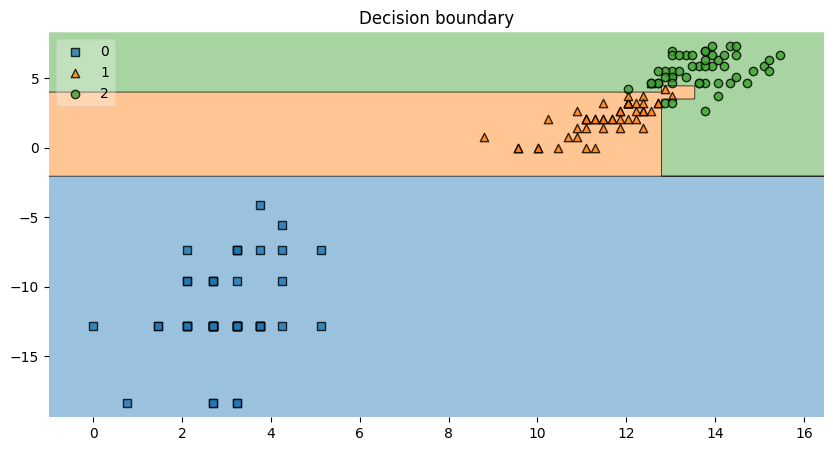

In [5]:
from mlxtend.plotting import plot_decision_regions

tree = DecisionTreeClassifier(max_depth=10, criterion="entropy", random_state=1)
tree.fit(np.log(X ** 8), y)
fig = plt.figure(figsize=(10,5))
labels = ['Decision Tree']
fig = plot_decision_regions(X=np.log(X ** 8), y=y, clf=tree, legend=2)
plt.title("Decision boundary")
plt.show()

Jakie wnioski możne sformuować na bazie granic decyzyjnych przedstawionych powyżej? W momencie pojawianie się dodatkowej próbki klasy *zielonej* (2), zostanie ona dobrze sklasyfikowana? Czy klasyfikator posiada dobre właściwości generalizujące?

In [42]:
#YOUR ANSWER HERE

Granice decyzyjne drzewa (max_depth=10):

    Kształt: Prostokątne regiony, wynikające z osiowo równoległych cięć.

    Szczegółowość: Głębokie drzewo tworzy bardzo szczegółowe granice, co może prowadzić do nadmiernego dopasowania (overfitting).

Klasyfikacja nowej próbki (klasa zielona – 2):

    Jeśli próbka znajduje się w regionie klasy zielonej, zostanie poprawnie sklasyfikowana.

    Blisko granicy istnieje ryzyko błędnej klasyfikacji ze względu na sztywność podziału.

Generalizacja:

    Model dobrze dopasowuje się do danych treningowych, ale może mieć problem z nowymi danymi.

    Zbyt skomplikowane granice mogą ograniczać zdolność do uogólniania.

Podsumowanie: Model skutecznie klasyfikuje próbki w „bezpiecznych” regionach, ale blisko granic może być mniej stabilny. Overfitting może ograniczać jego działanie na nowych danych.

### Zadanie 2

Proszę o wczytanie, opisanie zbioru danych: https://www.kaggle.com/datasets/mathchi/diabetes-data-set. Proszę o usunięcie danych None. Zbiór danych powinien być użyty do dalszych oblicze

In [6]:
#YOUR CODE HERE
import pandas as pd

# Wczytanie danych z pliku CSV 'diabetes.csv'
df = pd.read_csv('diabetes.csv')

print(df.__dataframe__)

# Usunięcie wierszy zawierających brakujące dane (NaN)
df_clean = df.dropna()

<bound method DataFrame.__dataframe__ of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       

### Zadanie 3

Proszę wytrenować zbiór z użyciem algorytmu drzewa decyzyjnego. Proszę pamiętać o odpowienim podziale na zbiór uczący i treningowy. Klasyfikator powinien być trenowany na zbiorze treningowym, a wynik jego skuteczności po trenowaniu obliczany w oparciu o zbiór testowy.

Proszę przygotować wyniki, trenując algorytm z użyciem różnych parametrów - należy przygotować wykresy (oś pionowa określa skuteczność, pozioma wartość parametru) pokazujące jak zmienia się skuteczność działania w zależności od zastosowanych wartości parametrów. Proszę o przygotowanie odpowiedniego porównania (tabela), co można zaobserwować?

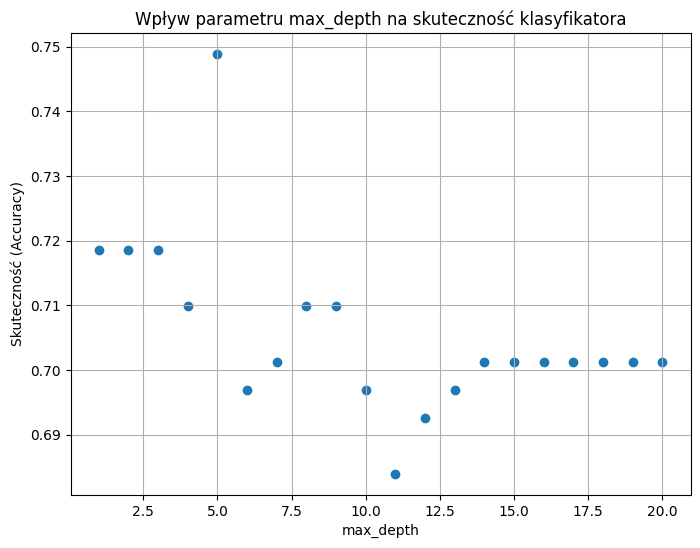

Wyniki dla parametru max_depth:
    max_depth  Accuracy
0           1  0.718615
1           2  0.718615
2           3  0.718615
3           4  0.709957
4           5  0.748918
5           6  0.696970
6           7  0.701299
7           8  0.709957
8           9  0.709957
9          10  0.696970
10         11  0.683983
11         12  0.692641
12         13  0.696970
13         14  0.701299
14         15  0.701299
15         16  0.701299
16         17  0.701299
17         18  0.701299
18         19  0.701299
19         20  0.701299


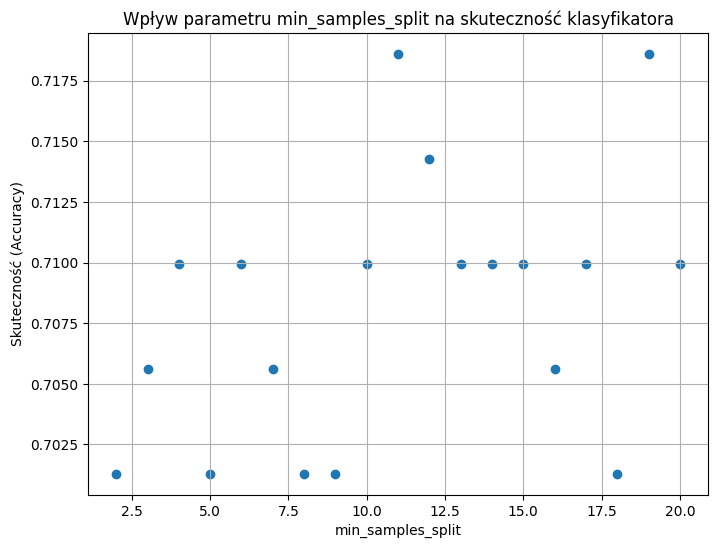

Wyniki dla parametru min_samples_split:
    min_samples_split  Accuracy
0                   2  0.701299
1                   3  0.705628
2                   4  0.709957
3                   5  0.701299
4                   6  0.709957
5                   7  0.705628
6                   8  0.701299
7                   9  0.701299
8                  10  0.709957
9                  11  0.718615
10                 12  0.714286
11                 13  0.709957
12                 14  0.709957
13                 15  0.709957
14                 16  0.705628
15                 17  0.709957
16                 18  0.701299
17                 19  0.718615
18                 20  0.709957


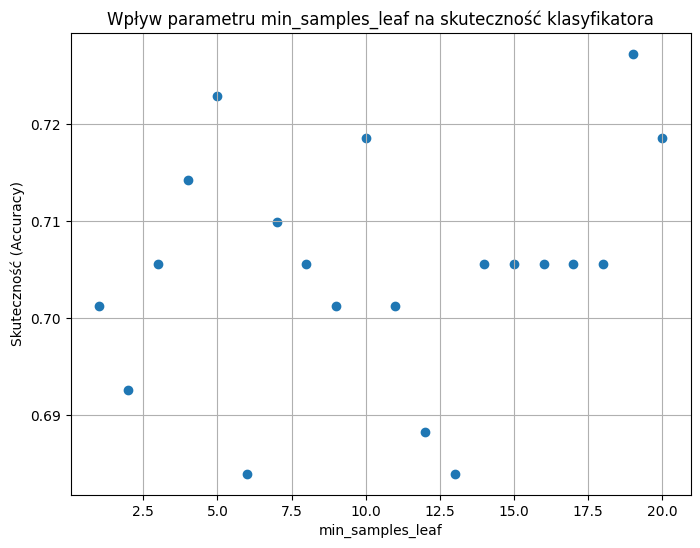

Wyniki dla parametru min_samples_leaf:
    min_samples_leaf  Accuracy
0                  1  0.701299
1                  2  0.692641
2                  3  0.705628
3                  4  0.714286
4                  5  0.722944
5                  6  0.683983
6                  7  0.709957
7                  8  0.705628
8                  9  0.701299
9                 10  0.718615
10                11  0.701299
11                12  0.688312
12                13  0.683983
13                14  0.705628
14                15  0.705628
15                16  0.705628
16                17  0.705628
17                18  0.705628
18                19  0.727273
19                20  0.718615


In [9]:
#YOUR CODE HERE

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Przygotowanie danych: oddzielenie cech (X) od etykiety (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Podział danych na zbiór treningowy i testowy (70% trening, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ------------------------
# Analiza wpływu parametru max_depth na skuteczność klasyfikatora
# ------------------------

# Lista możliwych wartości parametru max_depth (od 1 do 20)
max_depth_values = list(range(1, 21))
# Lista do przechowywania uzyskanej skuteczności (accuracy) dla każdej wartości max_depth
acc_max_depth = []

# Pętla iterująca po kolejnych wartościach max_depth
for depth in max_depth_values:
    # Inicjalizacja drzewa decyzyjnego z określoną głębokością
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    # Trenowanie modelu na danych treningowych
    clf.fit(X_train, y_train)
    # Predykcja etykiet na zbiorze testowym
    y_pred = clf.predict(X_test)
    # Obliczenie skuteczności (accuracy) modelu
    acc = accuracy_score(y_test, y_pred)
    # Dodanie wyniku do listy
    acc_max_depth.append(acc)

# Rysowanie wykresu wpływu parametru max_depth na skuteczność
plt.figure(figsize=(8,6))
plt.scatter(max_depth_values, acc_max_depth, marker='o')
plt.xlabel('max_depth')
plt.ylabel('Skuteczność (Accuracy)')
plt.title('Wpływ parametru max_depth na skuteczność klasyfikatora')
plt.grid(True)
plt.show()

# Tworzenie DataFrame z wynikami dla max_depth
df_max_depth = pd.DataFrame({'max_depth': max_depth_values, 'Accuracy': acc_max_depth})
print("Wyniki dla parametru max_depth:")
print(df_max_depth)

# ------------------------
# Analiza wpływu parametru min_samples_split na skuteczność klasyfikatora
# ------------------------

# Lista możliwych wartości parametru min_samples_split (od 2 do 20)
min_samples_split_values = list(range(2, 21))
# Lista do przechowywania skuteczności dla każdej wartości
acc_min_samples_split = []

# Pętla iterująca po kolejnych wartościach min_samples_split
for mss in min_samples_split_values:
    # Inicjalizacja drzewa decyzyjnego z określonym parametrem min_samples_split
    clf = DecisionTreeClassifier(min_samples_split=mss, random_state=42)
    # Trenowanie modelu na zbiorze treningowym
    clf.fit(X_train, y_train)
    # Predykcja na zbiorze testowym
    y_pred = clf.predict(X_test)
    # Obliczenie skuteczności
    acc = accuracy_score(y_test, y_pred)
    # Dodanie wyniku do listy
    acc_min_samples_split.append(acc)

# Rysowanie wykresu wpływu parametru min_samples_split na skuteczność
plt.figure(figsize=(8,6))
plt.scatter(min_samples_split_values, acc_min_samples_split, marker='o')
plt.xlabel('min_samples_split')
plt.ylabel('Skuteczność (Accuracy)')
plt.title('Wpływ parametru min_samples_split na skuteczność klasyfikatora')
plt.grid(True)
plt.show()

# Tworzenie DataFrame z wynikami dla min_samples_split
df_min_samples_split = pd.DataFrame({'min_samples_split': min_samples_split_values, 'Accuracy': acc_min_samples_split})
print("Wyniki dla parametru min_samples_split:")
print(df_min_samples_split)

# ------------------------
# Analiza wpływu parametru min_samples_leaf na skuteczność klasyfikatora
# ------------------------

# Lista możliwych wartości parametru min_samples_leaf (od 1 do 20)
min_samples_leaf_values = list(range(1, 21))
# Lista do przechowywania skuteczności dla każdej wartości
acc_min_samples_leaf = []

# Pętla iterująca po kolejnych wartościach min_samples_leaf
for msl in min_samples_leaf_values:
    # Inicjalizacja drzewa decyzyjnego z określonym parametrem min_samples_leaf
    clf = DecisionTreeClassifier(min_samples_leaf=msl, random_state=42)
    # Trenowanie modelu na danych treningowych
    clf.fit(X_train, y_train)
    # Predykcja etykiet na zbiorze testowym
    y_pred = clf.predict(X_test)
    # Obliczenie skuteczności
    acc = accuracy_score(y_test, y_pred)
    # Dodanie wyniku do listy
    acc_min_samples_leaf.append(acc)

# Rysowanie wykresu wpływu parametru min_samples_leaf na skuteczność
plt.figure(figsize=(8,6))
plt.scatter(min_samples_leaf_values, acc_min_samples_leaf, marker='o')
plt.xlabel('min_samples_leaf')
plt.ylabel('Skuteczność (Accuracy)')
plt.title('Wpływ parametru min_samples_leaf na skuteczność klasyfikatora')
plt.grid(True)
plt.show()

# Tworzenie DataFrame z wynikami dla min_samples_leaf
df_min_samples_leaf = pd.DataFrame({'min_samples_leaf': min_samples_leaf_values, 'Accuracy': acc_min_samples_leaf})
print("Wyniki dla parametru min_samples_leaf:")
print(df_min_samples_leaf)

### Zadanie 4

Drzewa decyzyjne mogą również szacować przewdopodobieństwo przynależności danej próbki do określonej klasy. Proszę przeprowadzić odpowiednie trenowanie klasyfikatora i określić jak zmienia się prawdopodobieństwo przynależności różnych próbek. Wystarczy odnaleźć odpowienią właściwość klasyfikatora i pokazać jakie jest zwracane prawdopodobieństwo dla kilku przykładów.

In [10]:
#YOUR CODE HERE

# Inicjalizacja i trenowanie drzewa decyzyjnego z ustalonym random_state
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Wybór pierwszych 5 próbek ze zbioru testowego do analizy
samples = X_test.iloc[:5]
print("\nWybrane próbki z zestawu testowego:")
print(samples)

# Obliczenie szacowanych prawdopodobieństw przynależności wybranych próbek do poszczególnych klas
probas = clf.predict_proba(samples)
print("\nSzacowane prawdopodobieństwa przynależności do klas:")
print(probas)

# Predykcja klas dla wybranych próbek
predicted_classes = clf.predict(samples)
print("\nPrzewidywane klasy dla wybranych próbek:")
print(predicted_classes)


Wybrane próbki z zestawu testowego:
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
668            6       98             58             33      190  34.0   
324            2      112             75             32        0  35.7   
624            2      108             64              0        0  30.8   
690            8      107             80              0        0  24.6   
473            7      136             90              0        0  29.9   

     DiabetesPedigreeFunction  Age  
668                     0.430   43  
324                     0.148   21  
624                     0.158   21  
690                     0.856   34  
473                     0.210   50  

Szacowane prawdopodobieństwa przynależności do klas:
[[0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]

Przewidywane klasy dla wybranych próbek:
[1 1 0 0 0]


### Zadanie 5

Proszę wyrysować granice decyzyjne dla klasyfikatora drzewa decyzyjnego utworzonego we wcześniejszym zadaniu. Jakie można sformuować wnioski?

c:\Users\Piotr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


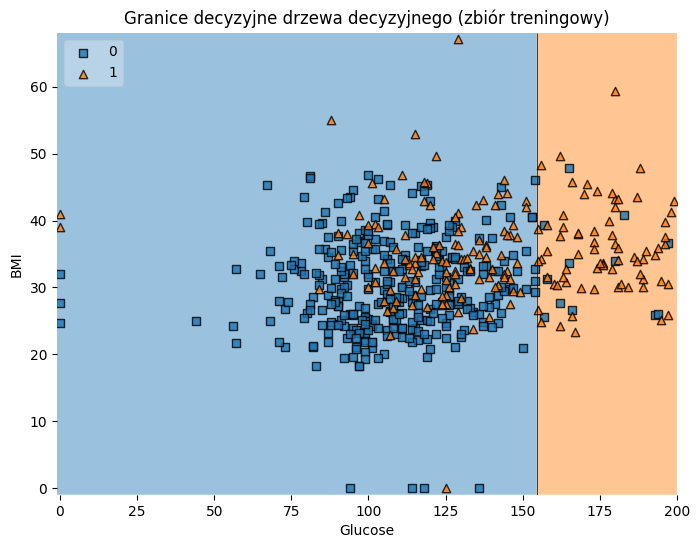

In [18]:
#YOUR CODE HERE
# Dla celów wizualizacji wybieramy tylko dwie cechy – przykładowo: Glucose oraz BMI
X = df[['Glucose', 'BMI']]
y = df['Outcome']

# Podział danych na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Trenowanie drzewa decyzyjnego (domyślnie kryterium Gini)
clf = DecisionTreeClassifier(random_state=42, max_depth=2)
clf.fit(X_train, y_train)

# Rysowanie granic decyzyjnych dla zbioru treningowego
plt.figure(figsize=(8,6))
plot_decision_regions(X=X_train.values, y=y_train.values, clf=clf, legend=2)
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Granice decyzyjne drzewa decyzyjnego (zbiór treningowy)")
plt.show()

### Zadanie 6

Proszę dokonać optymalizacji paramertrów (min. 3) modelu w oparciu o metodę przeszukiwania siatki: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#sklearn.model_selection.GridSearchCV

In [19]:
# YOUR CODE HERE

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Przygotowanie danych: oddzielenie cech (X) od etykiety (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Podział danych na zbiór treningowy i testowy (70% trening, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Inicjalizacja drzewa decyzyjnego z ustalonym random_state
clf = DecisionTreeClassifier(random_state=42)

# Definicja siatki parametrów do przeszukania
param_grid = {
    'max_depth': np.arange(1, 11),          # Głębokość drzewa od 1 do 10
    'min_samples_split': np.arange(2, 11),    # Minimalna liczba próbek potrzebna do podziału węzła (od 2 do 10)
    'min_samples_leaf': np.arange(1, 11)      # Minimalna liczba próbek w liściu (od 1 do 10)
}

# Konfiguracja wyszukiwania siatki z 5-krotną walidacją krzyżową i oceną accuracy
grid_search = GridSearchCV(estimator=clf,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)

# Przeprowadzenie wyszukiwania najlepszych parametrów na zbiorze treningowym
grid_search.fit(X_train, y_train)

# Wyświetlenie najlepszych parametrów i najlepszego wyniku walidacji krzyżowej
print("Najlepsze parametry:", grid_search.best_params_)
print("Najlepszy wynik CV:", grid_search.best_score_)

# Wybór najlepszego modelu z przeprowadzonego wyszukiwania
best_model = grid_search.best_estimator_

# Predykcja na zbiorze testowym
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

# Wyświetlenie skuteczności na zbiorze testowym oraz raportu klasyfikacji
print("Skuteczność na zbiorze testowym:", test_accuracy)
print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred))

Najlepsze parametry: {'max_depth': np.int64(8), 'min_samples_leaf': np.int64(7), 'min_samples_split': np.int64(2)}
Najlepszy wynik CV: 0.752319141571478
Skuteczność na zbiorze testowym: 0.7056277056277056

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.81      0.72      0.76       151
           1       0.56      0.69      0.62        80

    accuracy                           0.71       231
   macro avg       0.69      0.70      0.69       231
weighted avg       0.73      0.71      0.71       231

